# AMD Lemonade

Lemonade is a local inference server that serves a variety of models, including LLMs, VLMs, and speech models (speech-to-text and text-to-speech), on your own hardware through an OpenAI-compatible API. Any tool that supports that API can point to a model running on your machine instead of the cloud. With its ROCm backend, Lemonade offloads models onto the Radeon iGPU, keeping inference fast, private, and entirely on-device.

## Goals

* Learn how to set up your local LLM with Lemonade
* Run AI inference on an AMD GPU

The first step is to open a terminal session.

![](images/new_terminal.png)

## Start the Lemonade Server

Before we can run inference, we need to start the Lemonade server and load a model. The server provides an OpenAI-compatible API endpoint that we'll communicate with.

**In a separate terminal**, start the Lemonade server and load a model:

```bash
lemond &
lemonade pull Gemma-4-E2B-it-GGUF
lemonade run Gemma-4-E2B-it-GGUF
```

`lemonade run` drops you into an interactive chat once the model is loaded. Leave it running and confirm the server is healthy from another terminal:

```bash
curl http://localhost:13305/api/v1/health
```

**What this does:**
- `lemond &` starts the Lemonade server in the background, exposing an OpenAI-compatible API on port `13305`
- `lemonade pull` downloads the model if not already cached (stored in `~/.cache/lemonade/`)
- `lemonade run` loads the model into memory on the iGPU (via ROCm) and opens an interactive chat
- The server is ready to accept text queries for LLM inference

## Open Chat

Lemonade also ships a browser-based chat UI on the same port:
```
http://localhost:13305
```

#### (Optional) - Find other available models
```
lemonade list
```

## Test OpenAI API Server Directly

Let's verify the Lemonade server is working correctly by making a direct API call. This helps us understand the request/response format and confirm the model is responding.

The OpenAI-compatible API uses the standard chat completions format.

In [4]:
import requests

LEMONADE_SERVER_URL = "http://localhost:13305/api/v1/chat/completions"
MODEL = "Gemma-4-E2B-it-GGUF"

def ask(question: str):
    """Query the local LLM using the OpenAI chat completions format"""
    payload = {
        "model": MODEL,
        "messages": [
            {"role": "user", "content": question}
        ],
        "temperature": 0.2,
        "max_tokens": 3000
    }

    r = requests.post(LEMONADE_SERVER_URL, json=payload, timeout=120)
    r.raise_for_status()
    resp = r.json()
    return resp["choices"][0]["message"]["content"]

print(ask("How can I make a lemonade?"))

Making lemonade is incredibly simple and refreshing! Here is a classic recipe, followed by tips for customizing your perfect batch.

---

## 🍋 Classic Homemade Lemonade Recipe

This recipe focuses on achieving a perfect balance between tartness and sweetness.

### Ingredients

*   **Lemons:** 6–8 large lemons (about 1 to 1.5 cups of fresh juice)
*   **Sugar:** 1 cup granulated sugar (adjust to taste)
*   **Water:** 6 cups cold water
*   **Optional:** Ice cubes, garnish (lemon slices, mint)

### Equipment

*   Citrus juicer (or a good knife and bowl)
*   Large pitcher (at least 2 quarts)
*   Measuring cups and spoons

### Instructions

#### Step 1: Make the Simple Syrup (Optional, but recommended)
Simple syrup helps the sugar dissolve completely, preventing grainy lemonade.

1.  In a small saucepan, combine **1 cup of water** and **1 cup of sugar**.
2.  Heat over medium heat, stirring constantly, until the sugar is completely dissolved. Do not let it boil.
3.  Remove from heat and let t

### Prompting with an Image (VLM)

Lemonade doesn't just serve text LLMs — Gemma-4-E2B-it-GGUF itself has a vision layer, so the same OpenAI-compatible endpoint and the model we already loaded can accept image (base64) and text queries together, with no separate model needed.

The OpenAI-compatible API accepts images as base64-encoded data URLs inside the message content, alongside the text.

In [5]:
import base64
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

def b64_image(image_path: str) -> str:
    """Convert image to base64 string"""
    data = Path(image_path).read_bytes()
    return base64.b64encode(data).decode("utf-8")

def ask_with_image(image_path: str, question: str):
    """Query the local VLM with an image and question using the OpenAI format"""
    payload = {
        "model": MODEL,
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": question},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64_image(image_path)}"}}
                ]
            }
        ],
        "temperature": 0.2,
        "max_tokens": 3000
    }

    r = requests.post(LEMONADE_SERVER_URL, json=payload, timeout=120)
    r.raise_for_status()
    resp = r.json()

    # Display image alongside the model's answer
    img = cv2.imread(image_path)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(resp["choices"][0]["message"]["content"])
    ax.axis("off")



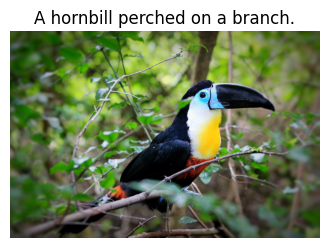

In [6]:
ask_with_image("images/toucan.jpg", "What's in this image? Be concise.")

### Speech: Text-to-Speech and Transcription (Audio)

Audio isn't attached to a chat message the way images are — Lemonade exposes it through two dedicated endpoints rather than the chat completions endpoint:
- `POST /api/v1/audio/speech` — text-to-speech (TTS), JSON body in, raw audio bytes out
- `POST /api/v1/audio/transcriptions` — speech-to-text (STT), multipart/form-data upload, WAV only

**In a separate terminal**, pre-pull the models these endpoints use so that the first call doesn't stall on a cold-start download:

```bash
lemonade pull kokoro-v1
lemonade pull Whisper-Base
```

Let's do a round trip: synthesize a short WAV clip with the TTS endpoint, then feed it straight back into the transcription endpoint to get the text back.

In [ ]:
import io

LEMONADE_SPEECH_URL = "http://localhost:13305/api/v1/audio/speech"
LEMONADE_TRANSCRIBE_URL = "http://localhost:13305/api/v1/audio/transcriptions"

# Text-to-speech: synthesize a WAV clip
tts_payload = {
    "model": "kokoro-v1",
    "input": "Lemonade also supports STT and TTS models that can run entirely offline on your own AMD Ryzen AI GPU.",
    "response_format": "wav"
}
tts_resp = requests.post(LEMONADE_SPEECH_URL, json=tts_payload, timeout=120)
tts_resp.raise_for_status()
audio_bytes = tts_resp.content

from IPython.display import Audio, display

display(Audio(data=audio_bytes))

# Speech-to-text: transcribe the WAV clip we just generated
files = {"file": ("speech.wav", io.BytesIO(audio_bytes), "audio/wav")}
data = {"model": "Whisper-Base"}
stt_resp = requests.post(LEMONADE_TRANSCRIBE_URL, files=files, data=data, timeout=120)
stt_resp.raise_for_status()

print(stt_resp.json()["text"])

## Try a Different Model

Lemonade's OpenAI-compatible endpoint doesn't change based on which model is loaded — swapping models is just a matter of pulling and running a different one, then pointing the `"model"` field of the request at its name. Everything else about the request/response structure stays identical.

**In a separate terminal**, pull and run a smaller, faster model:

```bash
lemonade pull Llama-3.2-1B-Instruct-GGUF
lemonade run Llama-3.2-1B-Instruct-GGUF
```

Now call it with the exact same request shape we've used throughout this notebook — only the `model` field changes:

In [ ]:
payload = {
    "model": "Llama-3.2-1B-Instruct-GGUF",
    "messages": [
        {"role": "user", "content": "What is a ROS 2 topic? Be concise."}
    ],
    "temperature": 0.2,
    "max_tokens": 256
}

r = requests.post(LEMONADE_SERVER_URL, json=payload, timeout=120)
r.raise_for_status()
print(r.json()["choices"][0]["message"]["content"])

## Hugging Face Compatibility

(At home) Beyond all the models already available on the Lemonade website, https://lemonade-server.ai/models.html, you may find even more Lemonade-compatible models on Hugging Face. Try downloading and running a few from https://huggingface.co/models — be sure to select the GGUF format in the *Libraries* search box.

<img src="images/huggingface.png" width="550" height="350">

<img src="images/lemonade_compatible_huggingface.png" width="150" height="350">

Hugging Face also gives you more flexibility, offering multiple quantization levels for the same model (e.g. `Q4_K_M`, `Q8_0`) that trade off speed, memory, and response quality. A higher quantization level can give noticeably better results for only a modest increase in memory usage.

<img src="images/different_quantizations.png" width="550" height="350">

To pull a model with a specific quantization, add an optional `:QUANT` suffix (e.g. `unsloth/Qwen3-8B-GGUF:Q4_K_M`):

```bash
lemonade pull unsloth/Qwen3-8B-GGUF:Q4_K_M
lemonade run unsloth/Qwen3-8B-GGUF:Q4_K_M
```

## Key Takeaways

Now you know:
- How to start the Lemonade server and load a model with `lemond`, `lemonade pull`, and `lemonade run`
- How to call Lemonade's OpenAI-compatible API directly for text, image (VLM), and audio (TTS/STT) queries
- How to swap models with minor code changes while the server is running
- How to pull additional GGUF models at different quantization levels

## What to Try Next

- Swap in a different chat or vision model and compare response quality and speed
- Test the LLM in one of your own local projects and analyze the agentic automation
- Adjust `temperature` (0.2 → 1.0) to see how much the answers vary, and raise or lower `max_tokens` to see where responses get cut off
- Prompt the VLM with your own image
- Try a different TTS voice, or a larger Whisper model for more accurate transcription
- Pull a model at a different quantization level and compare memory usage and response quality

## References

* [Lemonade](https://lemonade-server.ai/)
* [Hugging Face Models](https://huggingface.co/models)

**Continue to:** [03_robot_agents.ipynb](03_robot_agents.ipynb)